# COURSEWORK SPECIFICATION

## COM1011 - Fundamentals of Machine Learning

**Module Leader:** Chico Camargo

**Academic Year:** 2025/26

**Title:** Coursework 1

**Submission deadline:** 3rd November 2025, 12:00pm(noon).

This assessment contributes **30%** of the total module mark and assesses the following intended learning outcomes:

1. Understanding and identifying the compromises and trade-offs that must be made when using a machine learning approach;
2. Analysing problems from a data-centric point of view, choosing among a range of supervised and unsupervised machine learning techniques and using relevant software libraries to solve them
3. Stating the importance and difficulty of establishing machine learning solutions; 
4. Using elementary python for implementing machine learning algorithms. 
5. Identifying the compromises that must be made when translating theory into practice; 

**This is an individual assessment** and you are reminded of the University's regulations on collaboration and plagiarism. You must avoid plagiarism, collusion, and any academic misconduct behaviours. Further details about academic honesty and plagiarism can be found at https://ele.exeter.ac.uk/course/view.php?id=1957.

__________________________

# What to submit

You are required to submit your assignment **3rd November 2025 at 12:00pm(noon)**.

Please do all your work in this Jupyter notebook. Make a separate cell for every few lines of code, and use separate cells for text, like this one.
Save your file in the format `COM1011_STUDENTNUMBER.ipynb` and zip it.
For example, if your student number is 12345678, save your coursework as `COM1011_12345678.ipynb`.
Once you have done that, zip the file, producing a file called `COM1011_12345678.zip`. This is the file you will have to upload and submit to ELE.

This assignment will also use three additional files, named `AmesHousingSimple.csv`, `mnist_train.csv`, and `mnist_test.csv`. Do not include them in the `COM1011_STUDENTNUMBER.zip` file.

# Answer template

Please use this notebook for your coursework. Feel free to add more cells for your code and answers, but try to stick to this format. This will make it easier to mark everyone's work fairly.

___________________

In [1]:
# Run this cell so we know the versions of all libraries in your computer
!python -m pip list

Package                 Version
----------------------- -----------
asttokens               3.0.0
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
fonttools               4.60.1
ipykernel               7.0.1
ipython                 9.6.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.2
jupyter_client          8.6.3
jupyter_core            5.9.1
kiwisolver              1.4.9
matplotlib              3.10.7
matplotlib-inline       0.1.7
nest-asyncio            1.6.0
numpy                   2.3.4
packaging               25.0
pandas                  2.3.3
parso                   0.8.5
pillow                  12.0.0
pip                     25.2
platformdirs            4.5.0
prompt_toolkit          3.0.52
psutil                  7.1.1
pure_eval               0.2.3
Pygments                2.1

# Part A - AmesHousing Dataset: Linear Regression Analysis

This part of the assignment is based on the AmesHousing Dataset, which contains information about various features of houses.
It is real estate dataset from Ames, Iowa (USA) compiled by Dean De Cock for teaching data science. About 2,930 residential property sales with 80–82 features describing each house.
The original Ames dataset has over 80 features (such as lot size, number of rooms, garage details, neighborhood, etc.). To keep things clear and focused, we have reduced it to 7 numeric features + 1 target variable.
Target feature (what we predict): SalePrice (final sale price in USD).



____________________

## 1. Data Preparation (5 points)

1.1. Load the AmesHousingsimple.csv dataset, display the first 5 rows, and report the dataset’s shape and missing value statistics. (1 point)

1.2. Visualize the dataset:  Create scatterplots to explore the relationship between features and the target variable SalePrice. Here we want to plot the scatterplots Gr Liv Area VS SalePrice(1 points).


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('AmesHousingSimple.csv')
df.head()

,Lot Area,Overall Qual,Overall Cond,Year Built,Gr Liv Area,Bedroom AbvGr,Garage Cars,SalePrice
0,31770.0,6.0,5.0,1960.0,1656.0,3.0,2.0,215000
1,11622.0,5.0,6.0,NaN,896.0,2.0,1.0,105000
2,14267.0,6.0,NaN,1958.0,1329.0,3.0,1.0,172000
3,11160.0,7.0,5.0,1968.0,2110.0,3.0,2.0,244000
4,13830.0,5.0,5.0,1997.0,1629.0,3.0,2.0,189900


In [3]:
df.shape

(2930, 8)

In [4]:
df.isnull()

,Lot Area,Overall Qual,Overall Cond,Year Built,Gr Liv Area,Bedroom AbvGr,Garage Cars,SalePrice
0,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,False,False
2926,False,False,False,False,False,False,False,False
2927,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,False,False,False


Text(0, 0.5, 'Sale Price')

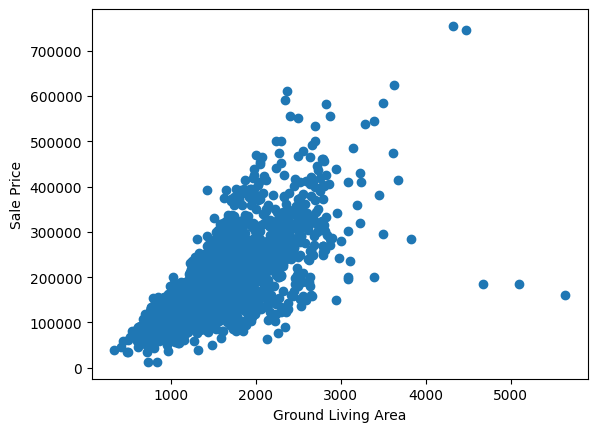

In [5]:
import matplotlib.pyplot as plt
plt.scatter(df['Gr Liv Area'],df['SalePrice'])
plt.xlabel('Ground Living Area')
plt.ylabel('Sale Price')

1.3. For each column, report how many values are missing. Which feature has the most missing values? （1 point）

In [6]:
# Answers here
df.isnull().sum()

Lot Area         146
Overall Qual     146
Overall Cond     146
Year Built       146
Gr Liv Area      146
Bedroom AbvGr    146
Garage Cars      147
SalePrice          0
dtype: int64

In [7]:
print('Garage Cars has the most missing value')

Garage Cars has the most missing value


1.4. Try one imputation strategies for missing values (1 point)

In [8]:
# Answers here
df = df.fillna(df.mean()) 

1.5. Calculate the correlation matrix between all numeric features in the dataset and plot the correlation matrix as a heatmap to visualize relationships between features and SalePrice.(1 point)(1 points).

In [9]:
# Answers here
cor_matrix = df.corr()
print(cor_matrix)

               Lot Area  Overall Qual  Overall Cond  Year Built  Gr Liv Area  \
Lot Area       1.000000      0.083939     -0.035743    0.018838     0.254903   
Overall Qual   0.083939      1.000000     -0.093190    0.570331     0.541865   
Overall Cond  -0.035743     -0.093190      1.000000   -0.357334    -0.107420   
Year Built     0.018838      0.570331     -0.357334    1.000000     0.227662   
Gr Liv Area    0.254903      0.541865     -0.107420    0.227662     1.000000   
Bedroom AbvGr  0.116043      0.061681     -0.015474   -0.058990     0.496710   
Garage Cars    0.168004      0.579782     -0.180005    0.515023     0.455281   
SalePrice      0.251495      0.786303     -0.100770    0.547096     0.684284   

               Bedroom AbvGr  Garage Cars  SalePrice  
Lot Area            0.116043     0.168004   0.251495  
Overall Qual        0.061681     0.579782   0.786303  
Overall Cond       -0.015474    -0.180005  -0.100770  
Year Built         -0.058990     0.515023   0.547096  
Gr L

<Axes: >

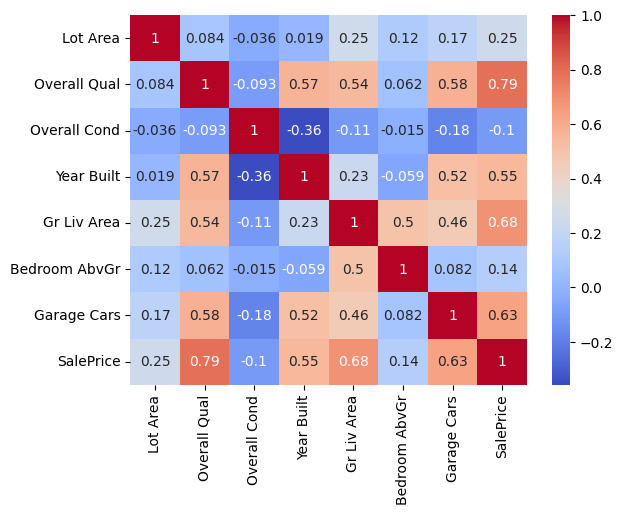

In [10]:
import seaborn as sns
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm")

## 2. Linear Regression (20 points)

Implement a linear regression model using only the 'Overall Qual', 'Year Built' and 'Bedroom AbvGr ' features to predict 'SalePrice'.
2.1 Separate the dataset into features (X) and target (y = SalePrice). Split into training and testing sets (80/20 split). (2 points)

2.2. Fit the model on the training data and make predictions on the test data. (4 points)

2.3. Calculate and print the Mean Squared Error (MSE) and R-squared score for both training and test sets. (3 points)

2.4. Make a scatterplot comparing the actual 'SalePrice' values vs. the predicted 'SalePrice' values. (3 points)

In [11]:
# Answers here
from sklearn.linear_model import LinearRegression
X = df[['Overall Qual', 'Year Built', 'Bedroom AbvGr']]
y = df['SalePrice']


In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_test_pred = lin_reg.predict(X_test)


In [17]:
#testing
lin_reg.predict([[6, 2002, 3]])

d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([191180.90912474])

In [18]:
from sklearn.metrics import mean_squared_error

In [19]:
y_train_pred = lin_reg.predict(X_train)

In [20]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

In [21]:
print(f'mse of the train set is: {train_mse}')
print(f'mse of the test set is: {test_mse}')

mse of the train set is: 2300150361.7445416
mse of the test set is: 2182780750.5690045


In [22]:
from sklearn.metrics import r2_score

In [23]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)


In [24]:
print(f'r2 of the train set is: {train_r2}')
print(f'r2 of the test set is: {test_r2}')

r2 of the train set is: 0.6408423024382967
r2 of the test set is: 0.6524483156155518


Text(0, 0.5, 'Predicted SalePrice')

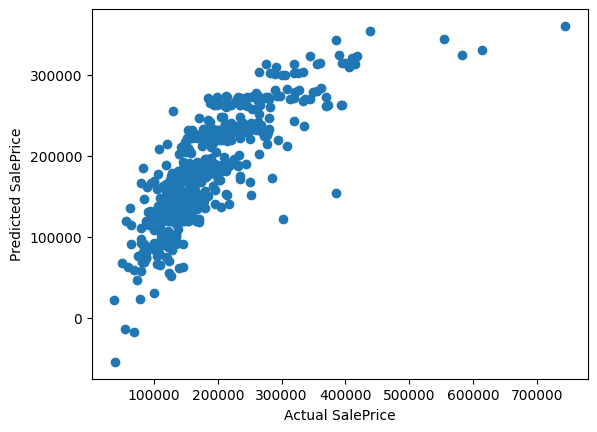

In [25]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

2.5.  Implement a linear regression model using all features. (3 points).

2.6.  Make a scatterplot comparing the actual 'SalePrice' values vs. the predicted 'SalePrice' values. (2 points).

2.7.  Compare its performance with the simple linear regression model using the metrics discussed so far. Which one does better? Print the result. (3 points)

In [26]:
# Answers here
X = df[['Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Gr Liv Area', 'Bedroom AbvGr', 'Garage Cars']]
y = df['SalePrice'] 

In [27]:
lin_reg_v2 = LinearRegression()
lin_reg_v2.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = lin_reg_v2.predict(X)

Text(0, 0.5, 'Predicted SalePrice')

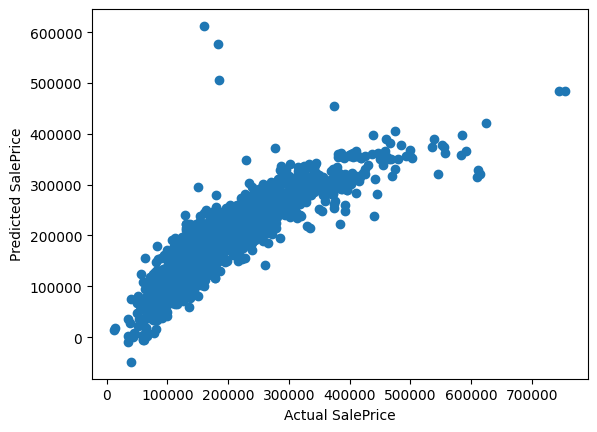

In [29]:
plt.scatter(y, y_pred)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

In [30]:
#model1 is the model with 3 features, model2 is the model with all features
model1_mse = mean_squared_error(y_test, y_test_pred)
print(model1_mse)
model2_mse = mean_squared_error(y, y_pred)
print(model2_mse)

2182780750.5690045
1463756125.612415


In [31]:
model1_r2 = r2_score(y_test, y_test_pred)
print(model1_r2)
model2_r2 = r2_score(y, y_pred)
print(model2_r2)

0.6524483156155518
0.7705605492328086


In [32]:
if model1_mse < model2_mse and model1_r2 > model2_r2:
    print('Result: Model 1 does better')
else:
    print('Result: Model 2 does better')

Result: Model 2 does better


_______________

## 3. Comparing Linear Regression with Polynomial Regression (15 points)

3.1. Implement a linear regression model and a polynomial regression model with degree 2 (a quadratic equation) using the 'Gr Liv Area' feature to predict 'SalePrice'. Do a train-test split, and compare how they perform by printing off their R² values and MSE on both the train and test data. (4 points)

3.2.  Create a scatter plot showing the predictions of both linear and polynomial models on the same graph, against the actual data. (3 points)

In [33]:
# Answers here
X = df[['Gr Liv Area']]
y = df['SalePrice']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
lin_reg_v3 = LinearRegression()
lin_reg_v3.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_train_pred = lin_reg_v3.predict(X_train)
y_test_pred = lin_reg_v3.predict(X_test)

In [37]:
from sklearn.preprocessing import PolynomialFeatures

In [38]:
poly_feat = PolynomialFeatures(degree=2)
X_train_poly_reg = poly_feat.fit_transform(X_train)
X_test_poly_reg = poly_feat.transform(X_test)



In [39]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly_reg, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_train_poly_pred = poly_reg.predict(X_train_poly_reg)
y_test_poly_pred = poly_reg.predict(X_test_poly_reg)

In [41]:
lin_reg_v3_train_mse = mean_squared_error(y_train, y_train_pred)
lin_reg_v3_test_mse = mean_squared_error(y_test, y_test_pred)
lin_reg_v3_train_r2 = r2_score(y_train, y_train_pred)
lin_reg_v3_test_r2 = r2_score(y_test, y_test_pred)
print('Linear Regression')
print(f'Train mse: {lin_reg_v3_train_mse}')
print(f'Test mse: {lin_reg_v3_test_mse}')
print(f'Train r2: {lin_reg_v3_train_r2}')
print(f'Test r2: {lin_reg_v3_test_r2}')

Linear Regression
Train mse: 3417585941.0385127
Test mse: 3292718395.5534916
Train r2: 0.4625295031526291
Test r2: 0.48991774576127234


In [42]:
poly_reg_train_mse = mean_squared_error(y_train, y_train_poly_pred)
poly_reg_test_mse = mean_squared_error(y_test, y_test_poly_pred)
poly_reg_train_r2 = r2_score(y_train, y_train_poly_pred)
poly_reg_test_r2 = r2_score(y_test, y_test_poly_pred)
print('Polynomial Regression')
print(f'Train mse: {poly_reg_train_mse}')
print(f'Test mse: {poly_reg_test_mse}')
print(f'Train r2: {poly_reg_train_r2}')
print(f'Test r2: {poly_reg_test_r2}')

Polynomial Regression
Train mse: 3355995601.7428083
Test mse: 3325901380.984532
Train r2: 0.47221557713390294
Test r2: 0.48477729644927126


d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

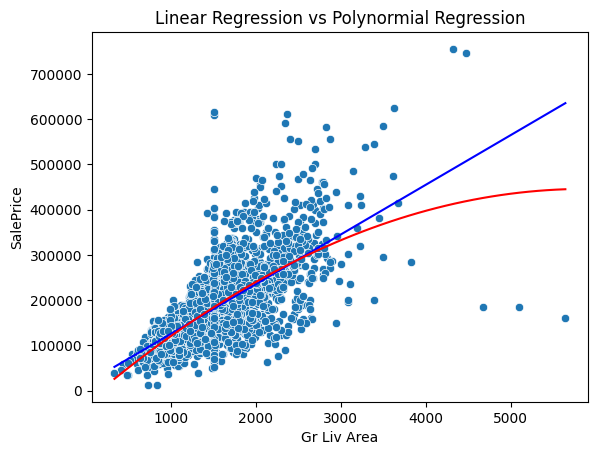

In [43]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)
lin_reg_line = np.linspace(X.min(), X.max())
plt.plot(lin_reg_line, lin_reg_v3.predict(lin_reg_line), color='blue', label='Linear Regression')
poly_reg_line = poly_feat.transform(lin_reg_line)
plt.plot(lin_reg_line, poly_reg.predict(poly_reg_line), color='red', label='Polynomial Regression')
plt.title('Linear Regression vs Polynormial Regression')
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.legend

3.3. Implement polynomial regression with degrees 1, 2, 3, and 4 using ALL features. First, plot the fitted regression curves for each degree on top of the data. Then, perform cross-validation and plot the mean squared error (MSE) for each degree to compare their performances. (4 points)

Hint: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

In [44]:
# Answers here
from sklearn.model_selection import cross_val_score, KFold
X = df[['Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Gr Liv Area', 'Bedroom AbvGr', 'Garage Cars']]
y = df['SalePrice']

d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, bu

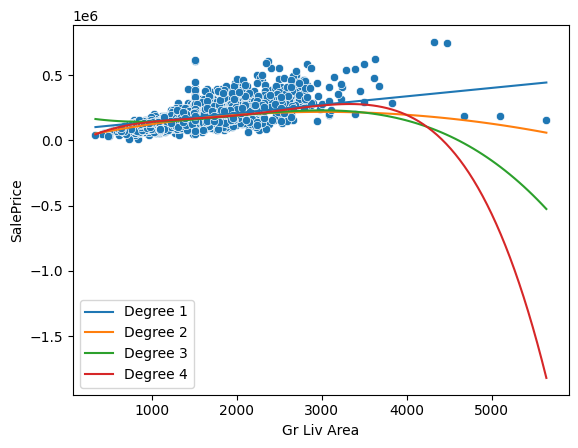

In [45]:
degrees = [1, 2, 3, 4]
cv_mse = []
kf = KFold(n_splits=5)

for degree in degrees:
    poly_feat = PolynomialFeatures(degree=degree)
    X_poly = poly_feat.fit_transform(X)
    poly_model = LinearRegression()
    mse = -cross_val_score(poly_model, X_poly, y, scoring='neg_mean_squared_error', cv=kf)
    mean_mse = mse.mean()
    cv_mse.append(mean_mse)
    poly_model.fit(X_poly, y)
    X_plot = np.linspace(X['Gr Liv Area'].min(), X['Gr Liv Area'].max(), 100)
    X_median = X.median().values.reshape(1, 7).repeat(100, axis=0)
    X_median[:, X.columns.get_loc('Gr Liv Area')] = X_plot
    X_plot_poly = poly_feat.transform(X_median)
    y_plot = poly_model.predict(X_plot_poly)
    curves = plt.plot(X_plot, y_plot, label=f'Degree {degree}')

sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.legend()

Text(0, 0.5, 'Cross-Validation MSE')

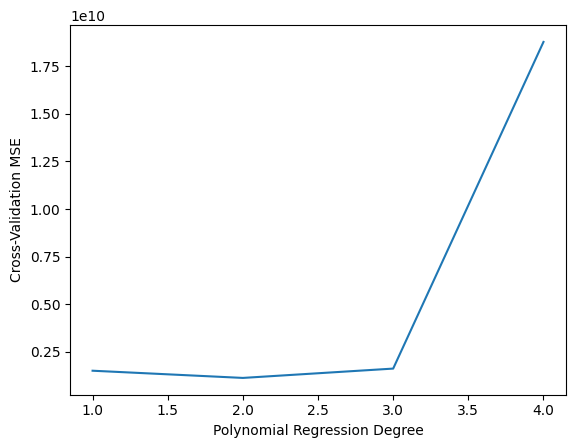

In [46]:
plt.plot(degrees, cv_mse)
plt.xlabel('Polynomial Regression Degree')
plt.ylabel('Cross-Validation MSE')

3.4. Discuss the trade-offs between model complexity and performance. Consider concepts such as overfitting, underfitting, and the bias-variance tradeoff. (4 points)

Answers here (double click to edit this cell)

Models with high complexity runs the risk of overfitting data. The result of capturing unnecessary data will increase variance. But at the same time it lowers the bias. Models with low complexity are likely to underfiting data. Which have a higher chance the model missing important trends, therefore the increasing the bias, but lowering variance. A good model should have a balance between bias and variance. By using the cross-validation method we can divide data and compare thier score against eachother. Therefore choosing the model with the best fit.

## 4. Feature Selection (10 points)

4.1. Looking at the performance of using selected features and full features in the linear logic regression tasks, which model performs better and why? Compare the Polynomial Regression models trained by only one feature and full features, which model performs better, and what might explain the difference in performance? (5 points)

Answers here (double click to edit this cell)

According to the r2 score and mse. The linear regression model with full feature has a higher r2 score and lower mse then the model with selected features only. So in this case, full features model performs better because it consist more information. For polynomial regression, comparing the mse of both model also with degree 2. The model with one feature does better. The reason in this case might be because the chosen feature is more relavent comparing to others

4.2. Discuss the impact of feature selection on model performance and interpretability. (5 points)


Answers here (double click to edit this cell)

For model performance, exclude irrelevant features will improve generalizaiton and reduce chances of overfitting. But removing important features will cause inaccuracy to the model. For model interpretability. With fewer features we are able to understnad which feature are truely more important to the model, yet sometimes secrifices detail trends that are crucial.


______________

# Part B - Classification

## 5. Data Preparation and Exploration (5 points)

5.1	Load the MNIST dataset (`mnist_train.csv` and `mnist_test.csv`) using the pandas library. (1 point)

5.2	Separate features (X) and labels (y) for both train and test data. (1 point) Note: In this dataset, the first column corresponds to the label (digit 0–9), and the remaining 784 columns are pixel features.

5.3	Normalize values of the features (X) so they are between 0 and 1. (1 point)

5.4 The input variables (X) should be 784-dimensional vectors. These actually represent 28x28 pixel images[1], but with all pixels represented as individual features. With that in mind, take 5 random data points (i.e. 5 random rows of the dataset), reshape them[2] from 784-dimensional vectors into 28x28 matrices, and display them (2 points).

[1] - https://en.wikipedia.org/wiki/MNIST_database

[2] - https://numpy.org/doc/2.0/reference/generated/numpy.reshape.html

In [47]:
# Answers here
train = pd.read_csv('mnist_train.csv')
test = pd.read_csv('mnist_test.csv')

In [48]:
X_train = train.iloc[:, 1:]
y_train = train.iloc[:, 0]
X_test = test.iloc[:, 1:]
y_test = test.iloc[:, 0]

In [49]:
X_train = X_train / 255
X_test = X_test / 255

In [50]:
random_row = np.random.choice(len(X_train), 5, replace=False)


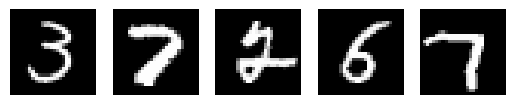

In [73]:
for i, idx in enumerate(random_row):
    image = X_train.iloc[idx].values.reshape(28, 28)
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

## 6. Classification using a Perceptron (15 points)

We will use the Perceptron classifier to distinguish between digit '0' and digit '1'. Use only the subset of the data corresponding to these two digits. 

6.1. 	Train the Perceptron on the training data for this binary classification task. (3 points)

6.2. 	Evaluate the Perceptron on the test set. Print out the test accuracy. (3 points)

6.3. 	Plot the confusion matrix showing how well the classifier performs on the test set for this binary task. (3 points)

6.4. Calculate and print the precision, recall, and F1 score for the Perceptron classifier. (3 points)

In [52]:
mask_train = (y_train == 0) | (y_train == 1)
X_train_bin = np.array(X_train[mask_train])
y_train_bin = np.array(y_train[mask_train])

mask_test = (y_test == 0) | (y_test == 1)
X_test_bin = np.array(X_test[mask_test])
y_test_bin = np.array(y_test[mask_test])

In [53]:
from sklearn.linear_model import Perceptron

In [54]:
perceptron = Perceptron()
perceptron.fit(X_train_bin, y_train_bin)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [55]:
from sklearn.metrics import accuracy_score
y_pred = perceptron.predict(X_test_bin)
accuracy = accuracy_score(y_test_bin, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9995271867612293


<Axes: >

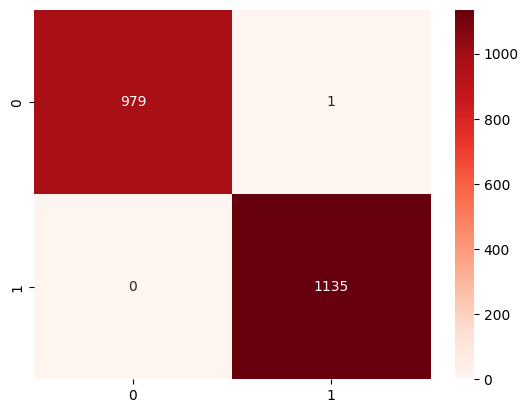

In [56]:
from sklearn.metrics import confusion_matrix

conf_matx = confusion_matrix(y_test_bin, y_pred)
sns.heatmap(conf_matx, annot=True, fmt='d', cmap='Reds')


In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

prec_scr = precision_score(y_test_bin, y_pred)
rec_scr = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)

print("Precision:", prec_scr)
print("Recall:", rec_scr)
print("F1 Score:", f1)

Precision: 0.9991197183098591
Recall: 1.0
F1 Score: 0.9995596653456627


 6.5 Implement a multi-class Perceptron classifier for all 10 digits. Train and evaluate it on the full dataset. Print the overall accuracy. (2 points)

In [58]:
X_train_multi = np.array(X_train)
y_train_multi = np.array(y_train)
X_test_multi = np.array(X_test)
y_test_multi = np.array(y_test)

In [59]:
perceptron_multi = Perceptron()
perceptron_multi.fit(X_train_multi, y_train_multi)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [60]:
y_pred_multi = perceptron_multi.predict(X_test_multi)
accuracy = accuracy_score(y_test_multi, y_pred_multi)
print("Overall accuracy:", accuracy)

Overall accuracy: 0.8857885788578858


 6.6 Plot a confusion matrix for your multi-class classifier. (1 point)

<Axes: >

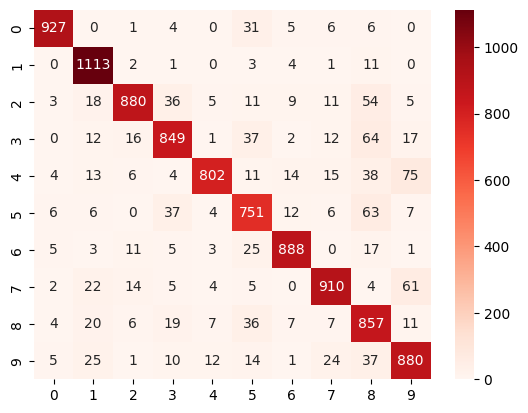

In [61]:
# Answers here
conf_matx = confusion_matrix(y_test_multi, y_pred_multi)
sns.heatmap(conf_matx, annot=True, fmt='d', cmap='Reds')

## 7. Classification with Logistic Regression (15 points)

Now we will implement a Logistic Regression classifier for the same binary classification task as with the perceptron.

7.1. 	Train the Logistic Regression model on the training data for this binary classification task. (3 points)

7.2. 	Evaluate the Logistic Regression model on the test set. Print out the test accuracy. (3 points)

7.3. 	Plot the confusion matrix for the Logistic Regression model on this binary task. (3 points)

7.4. 	Calculate and print the precision, recall, and F1 score for the Logistic Regression classifier (3 points)


In [62]:
# Answers here
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train_bin, y_train_bin)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
y_pred_bin = log_reg.predict(X_test_bin)
test_accuracy = accuracy_score(y_test_bin, y_pred)
print('Test accuracy:' , test_accuracy)

Test accuracy: 0.9995271867612293


<Axes: >

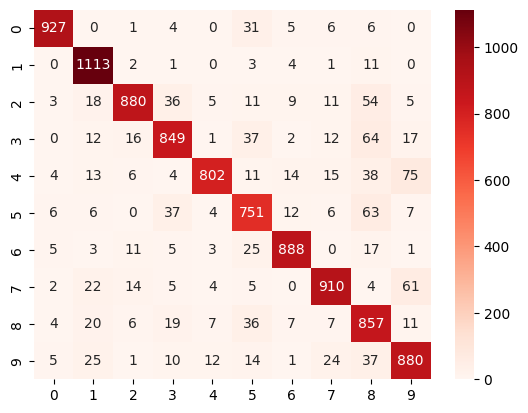

In [64]:
conf_matx_log = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(conf_matx, annot=True, fmt='d', cmap='Reds')

In [65]:
prec_scr = precision_score(y_test_bin, y_pred_bin)
rec_scr = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

In [66]:
print("Precision:", prec_scr)
print("Recall:", rec_scr)
print("F1 Score:", f1)

Precision: 0.9991197183098591
Recall: 1.0
F1 Score: 0.9995596653456627


7.5 Implement a multi-class Logistic Regression classifier for all 10 digits. Train and evaluate it on the full dataset. Print the overall accuracy. (2 points)

In [67]:
# Answers here
log_reg_multi = LogisticRegression()
log_reg_multi.fit(X_train_multi, y_train_multi)


d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursewrok 1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
y_pred_multi = log_reg_multi.predict(X_test_multi)
overall_acc = accuracy_score(y_test_multi, y_pred_multi)
print("Overall accuracy:", overall_acc)

Overall accuracy: 0.9261926192619262


 7.6 Plot the confusion matrix for the multi-class Logistic Regression classifier. (1 point)

<Axes: >

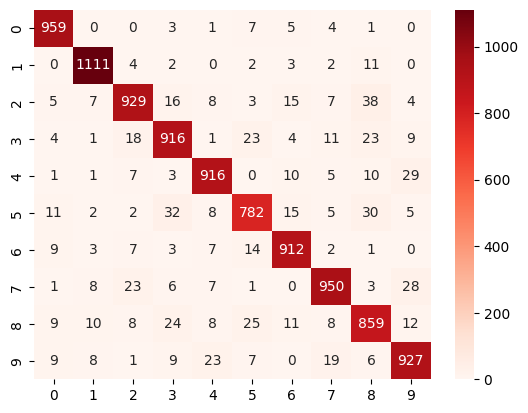

In [69]:
# Answers here
conf_matx_log_reg_multi = confusion_matrix(y_test_multi, y_pred_multi)
sns.heatmap(conf_matx_log_reg_multi, annot=True, fmt='d', cmap='Reds')

## 8. Model Comparison and Analysis (7 points)

8.1. For the multi-class Logistic Regression model, identify the three digits that are most frequently misclassified (i.e. classified wrong). Using the same `numpy.reshape` code as in question 5.4, display example images of these misclassified data points (4 points)

In [70]:
# Answers here
misclassified = np.where(y_test_multi != y_pred_multi)[0]
misclassified_labels = y_test_multi[misclassified]

In [71]:
labels, counts = np.unique(misclassified_labels, return_counts=True)
indices = np.argsort(-counts)
labels_top3 = labels[indices[:3]]
counts_top3 = counts[indices[:3]]

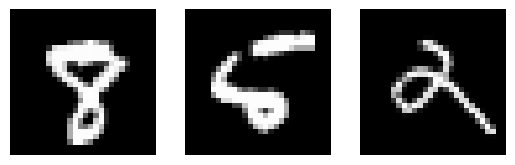

In [72]:
for i, digit in enumerate(labels_top3):
    idx = misclassified[np.where(misclassified_labels == digit)[0][0]]
    
    image = X_test_multi[idx].reshape(28, 28)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

8.2. Compare the performance of the Perceptron and Logistic Regression models on the binary classification and multi-class tasks. Which performed better? Explain why you think this is the case (3 points)

Answers here (double click to edit this cell)

On binary classification, both perceptron and logistic regression perform the same. According to the accuracy, precision, recall and f1 score, both of them have the same score on the 4 matrics. Because when the only 0 and 1, both models can easily can distinguish the data. Therefore they will make the same predictions when the data is the same. On multi-class tasks, logisitc regression does slightly better according to the accuracy score. Logistic regression uses softmax & cross-entropy,so it will be better at overlapping classes.

## 9. Understanding Machine Learning (8 points)

9.1. How might you modify the input data or feature representation to potentially improve the performance of these models on the MNIST dataset? Suggest at least two specific techniques (4 points).

Answers here (double click to edit this cell)

We can use Standardization for the input data. For example, we can use 0 for mean and 1 for standard deviation. It ensure the feature are equally important and it speeds up convergence. For feature representation, we can do Dimensionality Reduction like PCA. It helps reducing high-dimensional input to a smaller set of more important features. For example, reducing the features from 784 to only 100 more important ones, therefore it leads to a fater model training and delete the less important data.

9.2. Explain the importance of the train-test split in this context. What might happen if you trained and evaluated the models on the entire dataset without splitting?  (4 points)

Answers here (double click to edit this cell)

Because in perceptron and logistic regression they both learn patterns form the training data, by splitting the data, we can understand if modifying the data is actually helping to improve the model. If we train the data without splitting, there will be a risk of the model overfits. By calculating the precision recall and F1 scores and compare between the test and train data, we can know when the model is overfittig. 